# AI-Based Financial Time Series Forecasting using LSTM

# Data Preprocessing

## Objectives

- Load cleaned stock dataset
- Select closing price
- Normalize data
- Create 60-day sequences
- Split into train and test sets
- Save processed data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
import joblib

## Load Dataset

In [15]:
data = pd.read_csv("../data/clean_stock_data.csv")

data.head()

,Date,Open,High,Low,Close,Adj Close,Volume,MA50,MA200
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100178,469033600,NaN,NaN
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.094952,175884800,NaN,NaN
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.087983,105728000,NaN,NaN
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090160,86441600,NaN,NaN
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092774,73449600,NaN,NaN


## Convert Data

In [16]:
data["Date"] = pd.to_datetime(data["Date"])

data = data.sort_values("Date")

## Select Closing Price

In [17]:
closing_price = data[["Close"]]

closing_price.head()

,Close
0,0.128348
1,0.121652
2,0.112723
3,0.115513
4,0.118862


## Normalize Data

In [18]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(closing_price)

print("Scaled Shape:", scaled_data.shape)

Scaled Shape: (10468, 1)


## Visualize Scaled Data

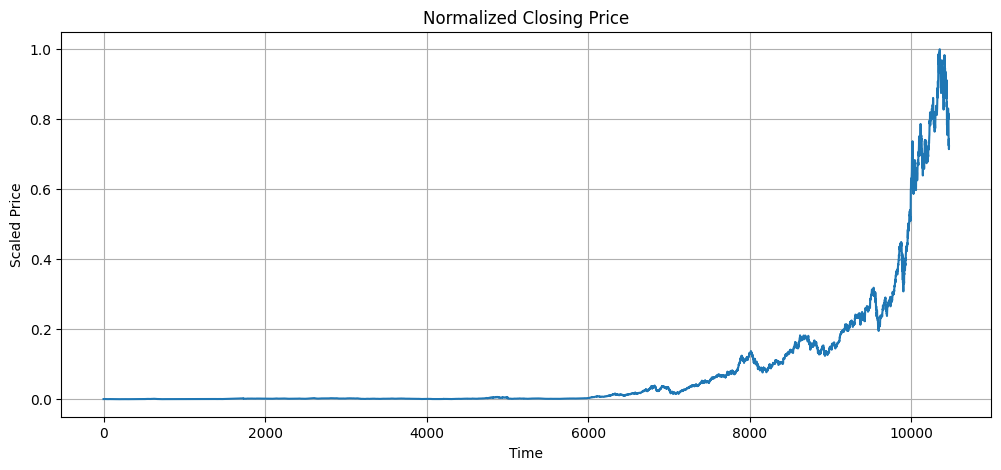

In [19]:
plt.figure(figsize=(12,5))

plt.plot(scaled_data)

plt.title("Normalized Closing Price")

plt.xlabel("Time")

plt.ylabel("Scaled Price")

plt.grid(True)

plt.show()

## Create Sequences

In [20]:
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (10408, 60, 1)
y Shape: (10408, 1)


## Train-Test Split

In [21]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 8326
Testing Samples: 2082


## Check Shapes

In [22]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8326, 60, 1)
X_test : (2082, 60, 1)
y_train: (8326, 1)
y_test : (2082, 1)


## Visualize One Sequence

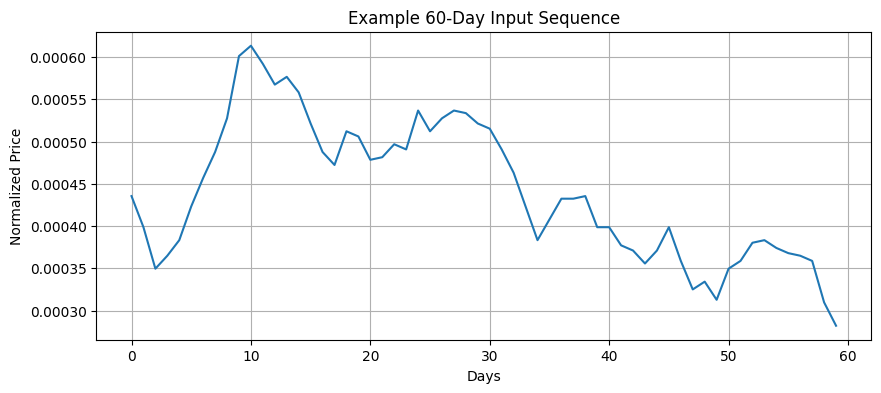

In [23]:
plt.figure(figsize=(10,4))

plt.plot(X_train[0].flatten())

plt.title("Example 60-Day Input Sequence")

plt.xlabel("Days")

plt.ylabel("Normalized Price")

plt.grid(True)

plt.show()

## Save Processed Data

In [24]:
np.save("../data/X_train.npy", X_train)
np.save("../data/X_test.npy", X_test)

np.save("../data/y_train.npy", y_train)
np.save("../data/y_test.npy", y_test)

print("Processed datasets saved successfully!")

Processed datasets saved successfully!


## Save Scaler

In [25]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


# Summary

Completed:

- Loaded cleaned stock dataset
- Selected closing prices
- Normalized data
- Generated 60-day sequences
- Split data into training and testing sets
- Saved processed datasets
- Saved MinMaxScaler